# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [25]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [26]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [27]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [28]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = pathlib.Path(root_dir)

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt")
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt").astype(np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt")
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt").astype(np.int32) - 1

    return X_train.astype(np.float32), y_train, X_test.astype(np.float32), y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 5. Quick Inspection


In [29]:
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [30]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [31]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


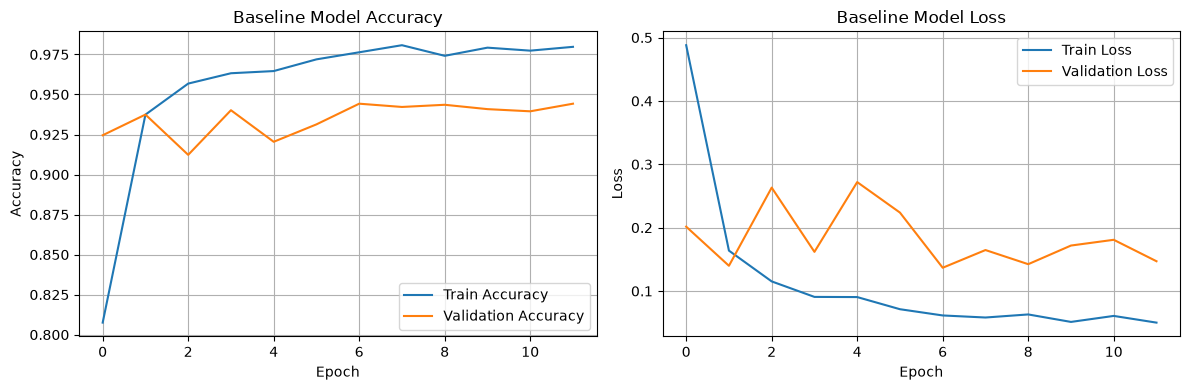

In [32]:
history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Model Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline Model Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Keras Test Accuracy: 0.9243

                    precision    recall  f1-score   support

           WALKING     0.9042    0.9899    0.9451       496
  WALKING_UPSTAIRS     0.8835    0.9342    0.9082       471
WALKING_DOWNSTAIRS     0.9885    0.8190    0.8958       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8666    0.9398    0.9017       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9243      2947
         macro avg     0.9291    0.9210    0.9228      2947
      weighted avg     0.9281    0.9243    0.9242      2947



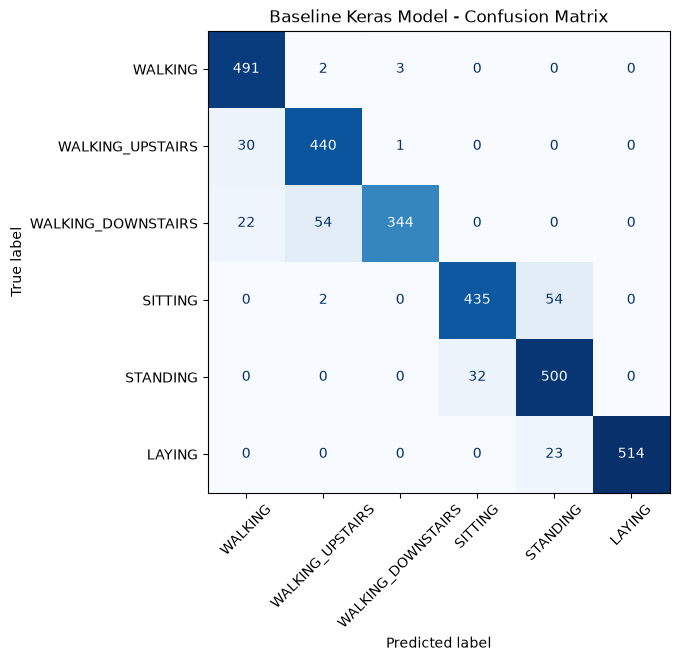

In [33]:
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [34]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [35]:
fp32_tflite_model = convert_to_tflite_fp32(baseline_model)
drq_tflite_model = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite_model = convert_to_tflite_float16(baseline_model)
int8_tflite_model = convert_to_tflite_int8(baseline_model)

fp32_size_kb = save_binary_model(fp32_tflite_model, "baseline_fp32.tflite")
drq_size_kb = save_binary_model(drq_tflite_model, "baseline_dynamic_range.tflite")
float16_size_kb = save_binary_model(float16_tflite_model, "baseline_float16.tflite")
int8_size_kb = save_binary_model(int8_tflite_model, "baseline_int8.tflite")

fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite_model, X_test, y_test)
drq_acc, drq_preds = evaluate_tflite_model(drq_tflite_model, X_test, y_test)
float16_acc, float16_preds = evaluate_tflite_model(float16_tflite_model, X_test, y_test)
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite_model, X_test, y_test)

print(f"FP32          - Acc: {fp32_acc:.4f}, Size: {fp32_size_kb:.2f} KB")
print(f"Dynamic Range - Acc: {drq_acc:.4f}, Size: {drq_size_kb:.2f} KB")
print(f"Float16       - Acc: {float16_acc:.4f}, Size: {float16_size_kb:.2f} KB")
print(f"Int8 (PTQ)    - Acc: {int8_acc:.4f}, Size: {int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmphjifyooh/assets


INFO:tensorflow:Assets written to: /tmp/tmphjifyooh/assets
2026-07-16 15:54:18.851672: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:54:18.851718: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:54:18.851853: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphjifyooh
2026-07-16 15:54:18.852627: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:54:18.852639: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphjifyooh
2026-07-16 15:54:18.854764: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:54:18.885629: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmphjifyooh
2026-07-16 15:54:18.897195: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpe90iv7mw/assets


INFO:tensorflow:Assets written to: /tmp/tmpe90iv7mw/assets
2026-07-16 15:54:19.640563: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:54:19.640610: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:54:19.640746: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpe90iv7mw
2026-07-16 15:54:19.641563: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:54:19.641575: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpe90iv7mw
2026-07-16 15:54:19.643798: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:54:19.670637: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpe90iv7mw
2026-07-16 15:54:19.678338: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp2pusfamo/assets


INFO:tensorflow:Assets written to: /tmp/tmp2pusfamo/assets
2026-07-16 15:54:20.435598: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:54:20.435645: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:54:20.435790: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp2pusfamo
2026-07-16 15:54:20.436560: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:54:20.436570: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp2pusfamo
2026-07-16 15:54:20.438347: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:54:20.466931: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp2pusfamo
2026-07-16 15:54:20.475391: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpestnc272/assets


INFO:tensorflow:Assets written to: /tmp/tmpestnc272/assets
/home/parksad/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-16 15:54:21.257071: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:54:21.257112: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:54:21.257228: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpestnc272
2026-07-16 15:54:21.257730: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:54:21.257740: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpestnc272
2026-07-16 15:54:21.259146: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

FP32          - Acc: 0.9243, Size: 726.75 KB
Dynamic Range - Acc: 0.9243, Size: 186.14 KB
Float16       - Acc: 0.9243, Size: 365.77 KB
Int8 (PTQ)    - Acc: 0.9237, Size: 185.35 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [36]:
ptq_results = pd.DataFrame([
    ["Baseline", "FP32", fp32_acc, fp32_size_kb],
    ["Baseline", "Dynamic Range", drq_acc, drq_size_kb],
    ["Baseline", "Float16", float16_acc, float16_size_kb],
    ["Baseline", "Int8 (PTQ)", int8_acc, int8_size_kb],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])

ptq_results


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.924330,726.750000
1,Baseline,Dynamic Range,0.924330,186.140625
2,Baseline,Float16,0.924330,365.773438
3,Baseline,Int8 (PTQ),0.923651,185.351562


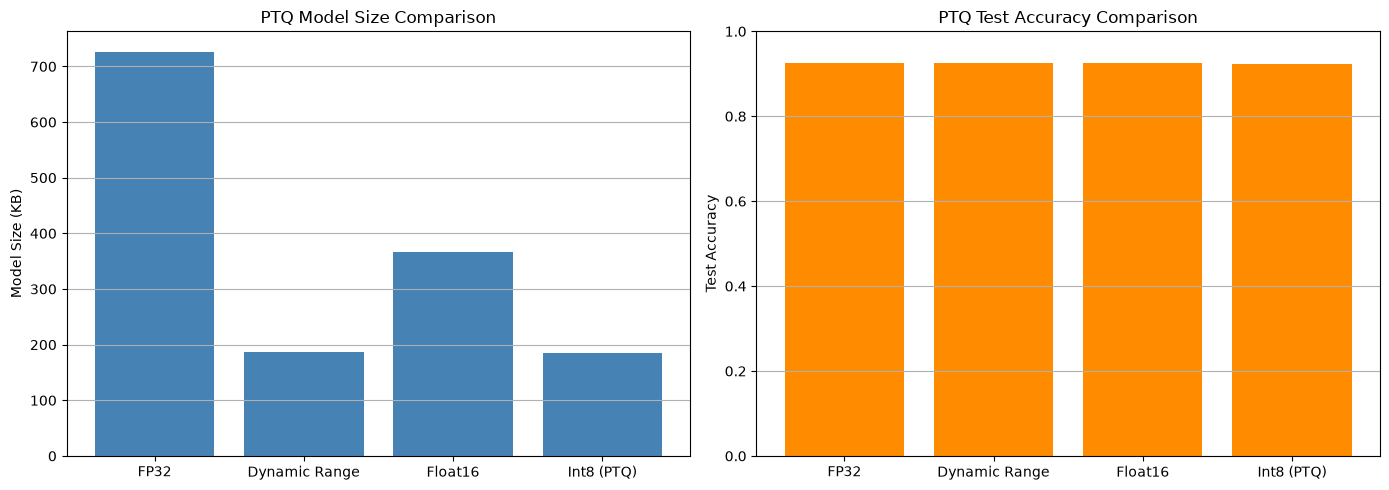

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ptq_results["Format"], ptq_results["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("PTQ Model Size Comparison")
axes[0].grid(axis="y")

axes[1].bar(ptq_results["Format"], ptq_results["Test Accuracy"], color="darkorange")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("PTQ Test Accuracy Comparison")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


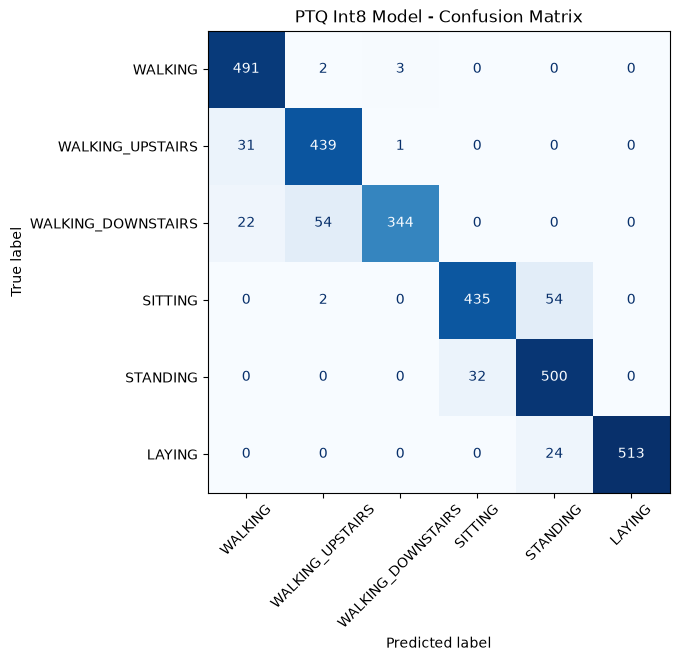

                    precision    recall  f1-score   support

           WALKING     0.9026    0.9899    0.9442       496
  WALKING_UPSTAIRS     0.8833    0.9321    0.9070       471
WALKING_DOWNSTAIRS     0.9885    0.8190    0.8958       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8651    0.9398    0.9009       532
            LAYING     1.0000    0.9553    0.9771       537

          accuracy                         0.9237      2947
         macro avg     0.9285    0.9204    0.9222      2947
      weighted avg     0.9275    0.9237    0.9235      2947



In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("PTQ Int8 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [39]:
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_1 (Quantize  (None, 561)               3         
 Layer)                                                          
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [40]:
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 2s 7ms/step - loss: 0.0494 - accuracy: 0.9845 - val_loss: 0.1247 - val_accuracy: 0.9456
Epoch 2/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0393 - accuracy: 0.9864 - val_loss: 0.1268 - val_accuracy: 0.9463
Epoch 3/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0385 - accuracy: 0.9871 - val_loss: 0.1364 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0351 - accuracy: 0.9879 - val_loss: 0.1259 - val_accuracy: 0.9463
Epoch 5/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0339 - accuracy: 0.9891 - val_loss: 0.1655 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0337 - accuracy: 0.9883 - val_loss: 0.1487 - val_accuracy: 0.9497
Epoch 7/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0340 - accuracy: 0.9881 - val_loss: 0.1310 - val_accuracy: 0.9490
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [41]:
qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_keras_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_keras_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))


QAT Keras Test Accuracy: 0.9359

                    precision    recall  f1-score   support

           WALKING     0.9187    0.9798    0.9483       496
  WALKING_UPSTAIRS     0.9595    0.9045    0.9311       471
WALKING_DOWNSTAIRS     0.9591    0.9500    0.9545       420
           SITTING     0.9632    0.8534    0.9050       491
          STANDING     0.8445    0.9699    0.9029       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9359      2947
         macro avg     0.9408    0.9352    0.9363      2947
      weighted avg     0.9398    0.9359    0.9361      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [42]:
qat_int8_tflite_model = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite_model, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite_model, X_test, y_test)

print(f"QAT Int8 - Acc: {qat_int8_acc:.4f}, Size: {qat_int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpwmp7e6qs/assets


INFO:tensorflow:Assets written to: /tmp/tmpwmp7e6qs/assets


QAT Int8 - Acc: 0.9359, Size: 185.77 KB


/home/parksad/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-16 15:54:29.218881: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:54:29.218920: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:54:29.219046: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwmp7e6qs
2026-07-16 15:54:29.220864: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:54:29.220875: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpwmp7e6qs
2026-07-16 15:54:29.225371: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:54:29.270216: I tensorflow/cc/saved_model/load

## 12. PTQ Int8 vs QAT Int8


In [43]:
ptq_vs_qat_results = pd.DataFrame([
    ["PTQ Int8", int8_acc, int8_size_kb],
    ["QAT Int8", qat_int8_acc, qat_int8_size_kb],
], columns=["Model", "Test Accuracy", "Model Size (KB)"])

ptq_vs_qat_results


,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.923651,185.351562
1,QAT Int8,0.935867,185.773438


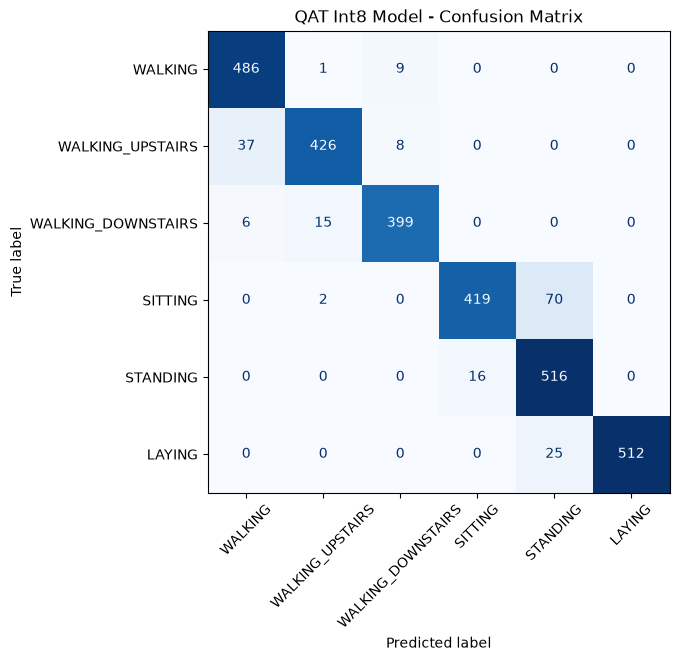

                    precision    recall  f1-score   support

           WALKING     0.9187    0.9798    0.9483       496
  WALKING_UPSTAIRS     0.9595    0.9045    0.9311       471
WALKING_DOWNSTAIRS     0.9591    0.9500    0.9545       420
           SITTING     0.9632    0.8534    0.9050       491
          STANDING     0.8445    0.9699    0.9029       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9359      2947
         macro avg     0.9408    0.9352    0.9363      2947
      weighted avg     0.9398    0.9359    0.9361      2947



In [44]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT Int8 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, qat_int8_preds, target_names=class_names, digits=4))


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
PTQ Int8, but it was 185.35KB compared to QAT Int8's 185.77KB, so it was barely smaller.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
QAT Int8 - 93.59%.
3. Did QAT improve the final int8 model compared with PTQ int8?
Yes, with a 93.59% to 92.37%.
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
Because it's already pre-extracted into 561 features, so no need for raw signal processing or anything like that since a simple dense net can do just fine.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
Probably QAT Int because it is essentially the same size as PTQ, but better accuracy.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
